In [5]:
# LangGraph에서 상태 그래프를 만들기 위한 클래스와
# 그래프의 시작/끝을 나타내는 상수를 가져옵니다.
from langgraph.graph import StateGraph, START, END

# 딕셔너리 형태의 타입(키/값 타입을 명시한 dict)을
# 정의할 수 있게 해주는 도구입니다.
from typing_extensions import TypedDict

# Command: 노드가 "다음에 어디로 갈지"와
# "상태를 어떻게 수정할지"를 함께 명령할 수 있게 해주는 타입입니다.
from langgraph.types import Command


In [6]:
# 그래프에서 오고 가는 상태(state)의 모양을 정의합니다.
# transfer_reason: 상담/처리를 넘기는 이유를 설명하는 문자열입니다.
class State(TypedDict):
  transfer_reason: str

# 위에서 정의한 State 타입을 사용하는 상태 그래프를 만듭니다.
graph_builder = StateGraph(State)

In [ ]:
# Literal 타입은 변수나 함수의 반환값이 특정 값(리터럴) 중 하나임을 타입 힌트로 표현할 때 사용합니다.
# 예시:
#   def direction(d: Literal["left", "right"]) -> None:
#     # d는 "left" 또는 "right" 만 받을 수 있습니다.
#     pass
from typing import Literal

# triage_node:
#   - 현재 상태를 보고, 어떤 팀으로 넘길지 결정하는 노드라고 생각하면 됩니다.
#   - 여기서는 단순히 account_support 로만 보내도록 고정되어 있습니다.
#   - 반환 타입이 Command[...] 인 것이 포인트입니다.
#     → 다음에 갈 노드(goto) + 상태 변경(update)을 함께 지시할 수 있습니다.
def triage_node(state: State) -> Command[Literal["account_support", "tech_support"]]:
  return Command(
    # goto: 다음에 실행할 노드 이름을 직접 지정합니다.
    goto="account_support",
    # update: 상태를 어떻게 바꿀지 딕셔너리 형태로 지정합니다.
    update={
      "transfer_reason": "The user wants to change password.",
    },
  )

# tech_support: 기술 지원 팀에 연결되었을 때 실행될 노드(예시) 입니다.
# 여기서는 아무 것도 하지 않고 빈 dict 를 반환합니다.
def tech_support(state: State):
  return {}

# account_support: 계정 관련 지원 팀에 연결되었을 때 실행될 노드입니다.
# 여기서는 단순히 메시지를 출력만 합니다.
def account_support(state: State):
  print("account_support running")
  return {}
  

In [8]:
# 그래프에 사용할 노드들을 등록합니다.
graph_builder.add_node("triage_node", triage_node)
graph_builder.add_node("tech_support", tech_support)
graph_builder.add_node("account_support", account_support)

# START 에서 triage_node 로 이동합니다.
# triage_node 안에서 Command 를 반환하면서
# 다음에 갈 노드(goto)를 직접 정하게 됩니다.
graph_builder.add_edge(START, "triage_node")

# tech_support, account_support 에서 그래프를 종료합니다.
# (둘 중 어디로 가든 한 번 실행 후 END 로 이동하는 구조입니다.)
graph_builder.add_edge("tech_support", END)
graph_builder.add_edge("account_support", END)


In [9]:
# 지금까지 정의한 노드, 상태, 간선 정보를 이용해서
# 실제로 실행 가능한 그래프 객체를 만듭니다.
graph = graph_builder.compile()

# graph.invoke({}) 를 호출하면 그래프를 "한 번 실행" 합니다.
# - START → triage_node 로 진입
# - triage_node 가 Command(goto="account_support", ...) 를 반환
#   → LangGraph 가 다음 노드를 account_support 로 강제로 보냅니다.
# - account_support 가 실행되면서 "account_support running" 을 출력하고
#   END 로 이동하면서 그래프 실행이 끝납니다.
graph.invoke({})

account_support running


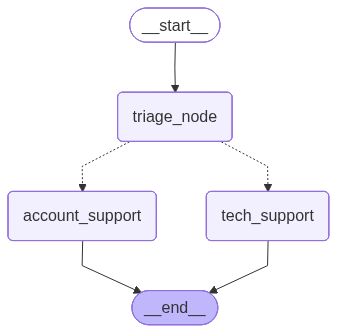

In [10]:
graph